# Supervised Fine-Tuning (SFT) of Gemma 2 2B — A Complete Learning Notebook

This notebook takes the **base** `google/gemma-2-2b` model and teaches it to follow
instructions using **Supervised Fine-Tuning (SFT)** with **LoRA** adapters.

Unlike the original notebook (which only *loaded and ran* Gemma), this one walks through
the **entire SFT pipeline** end to end, and at every stage produces the graphs, logs, and
logits you'd want when actually learning how fine-tuning works:

| Stage | What you'll see |
|---|---|
| Data | Category distribution, length histograms |
| Before training | Sample generations, next-token logits, baseline perplexity |
| Training | Live loss/log-history, learning-rate schedule, gradient norm, GPU memory |
| After training | Same generations/logits/perplexity, side-by-side with baseline |
| Wrap-up | Merged model saved to disk, full hyper-parameter + metric summary |

**Base model:** `google/gemma-2-2b` (not `-it`) — SFT is exactly the process used to turn a
base model into an instruction-following one, so we fine-tune the base model ourselves
instead of just downloading the already-tuned `-it` checkpoint.

**Dataset:** [`databricks/databricks-dolly-15k`](https://huggingface.co/datasets/databricks/databricks-dolly-15k) —
15,011 human-written instruction/response pairs across 8 task categories (open QA,
summarization, brainstorming, classification, etc.). It's small, permissively licensed,
and well suited to a single-GPU Colab run.

**Method:** [TRL](https://huggingface.co/docs/trl) `SFTTrainer` + [PEFT](https://huggingface.co/docs/peft) LoRA adapters
(parameter-efficient fine-tuning — we train ~0.1–1% of the model's parameters instead of
all 2B).

## What is Supervised Fine-Tuning (SFT)?

A base language model like `gemma-2-2b` is trained only to predict the next token on huge
amounts of raw text. It's fluent, but it has no notion of "answer the user's question" —
if you prompt it with a question, it's just as likely to continue the text with *another*
question, or ramble off-topic.

**SFT** fixes this by further training the model on a curated set of
`(instruction, response)` pairs, formatted the way we want the model to behave at
inference time. The training objective is still next-token prediction — cross-entropy
loss — but now:

1. Every example is wrapped in a **chat template** (Gemma uses `<start_of_turn>` /
   `<end_of_turn>` markers).
2. The loss is computed **only on the response tokens** (`completion_only_loss=True`) —
   we don't want to "reward" the model for predicting the instruction itself, only for
   predicting a good answer to it.
3. Because full fine-tuning of every weight is expensive, we use **LoRA**: we freeze the
   base model and inject small trainable low-rank matrices into the attention/MLP
   projection layers. This cuts trainable parameters and GPU memory dramatically while
   still moving the model's behavior a long way.

By the end of this notebook you'll be able to directly compare *"the same prompt, before
vs. after SFT"* — in generated text, in raw next-token probabilities, and in perplexity.

## 0. Colab setup

In Colab, select **Runtime → Change runtime type → T4 GPU** (or better — an L4/A100 will
train faster). Training a 2B model with LoRA comfortably fits on a free-tier T4 (16 GB).

Gemma access on Hugging Face requires accepting Google's Gemma license and being logged
in to Hugging Face (next section).

In [1]:
# Check GPU
!nvidia-smi

Wed Sep 16 02:54:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   39C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install the required libraries.
# transformers/trl/peft move fast — we pin nothing so Colab grabs current releases,
# but we print versions right after so you know exactly what ran.
!pip -q install -U transformers accelerate peft trl datasets huggingface_hub sentencepiece evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.4 MB/s eta 0:00:00


In [3]:
import transformers, peft, trl, datasets, torch

print("transformers:", transformers.__version__)
print("peft        :", peft.__version__)
print("trl         :", trl.__version__)
print("datasets    :", datasets.__version__)
print("torch       :", torch.__version__)
print("CUDA avail  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

transformers: 5.17.0
peft        : 0.21.0
trl         : 1.13.0
datasets    : 5.0.1
torch       : 2.11.0+cu128
CUDA avail  : True
GPU         : NVIDIA L4


## 1. Hugging Face login

Create a Hugging Face token with access to the Gemma model, then run this cell.
You can create/manage tokens at Hugging Face → Settings → Access Tokens.

**Do not paste your token directly into notebook code.**

In [4]:
from huggingface_hub import login

login()  # Enter your Hugging Face token when prompted

## 2. Imports and reproducibility

We fix every random seed we can so that re-running this notebook gives comparable
(not necessarily bit-identical) results.

In [5]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainerCallback,
)
from peft import LoraConfig, PeftModel
from trl import SFTConfig, SFTTrainer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_ID = "google/gemma-2-2b"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if (DEVICE == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32

print("Model :", MODEL_ID)
print("Device:", DEVICE)
print("Dtype :", DTYPE)

Model : google/gemma-2-2b
Device: cuda
Dtype : torch.bfloat16


## 3. Load and explore the dataset

**Dataset:** `databricks/databricks-dolly-15k`. Each row has:

- `instruction` — the task/question
- `context` — optional supporting text (empty for many rows)
- `response` — the target answer we want the model to learn to produce
- `category` — task type (`open_qa`, `summarization`, `brainstorming`, ...)

We subsample it for a Colab-friendly training run — increase `N_TRAIN` / `N_VAL` if you
have a bigger GPU or more time.

In [6]:
raw_dataset = load_dataset("databricks/databricks-dolly-15k", split="train")

print("Total examples:", len(raw_dataset))
print("Columns:", raw_dataset.column_names)
print()
print("Example row:")
for k, v in raw_dataset[0].items():
    print(f"  {k}: {v!r}")

README.md:   0%|          | 0.00/8.20k [00:00<?, ?B/s]

databricks-dolly-15k.jsonl: reconstructing file:   0%|          |  0.00B / 13.1MB            

databricks-dolly-15k.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Total examples: 15011
Columns: ['instruction', 'context', 'response', 'category']

Example row:
  instruction: 'When did Virgin Australia start operating?'
  context: "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney."
  response: 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.'
  category: 'closed_qa'


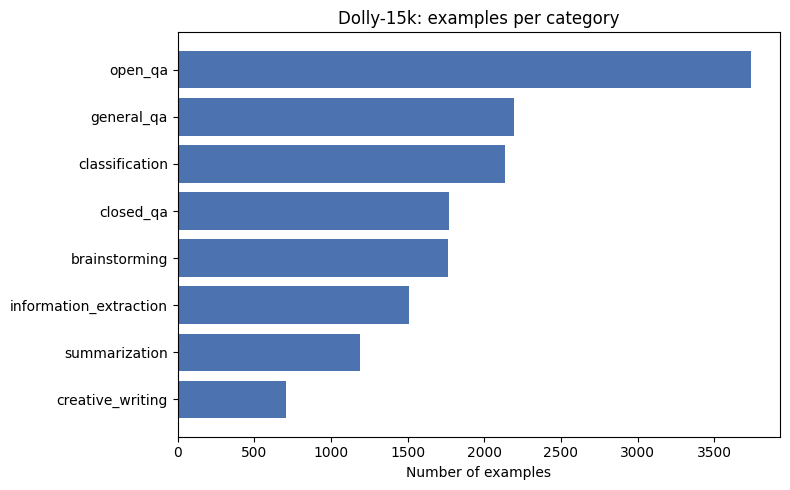

In [7]:
# --- Graph 1: category distribution -----------------------------------------
category_counts = pd.Series(raw_dataset["category"]).value_counts().sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(category_counts.index, category_counts.values, color="#4C72B0")
plt.xlabel("Number of examples")
plt.title("Dolly-15k: examples per category")
plt.tight_layout()
plt.show()

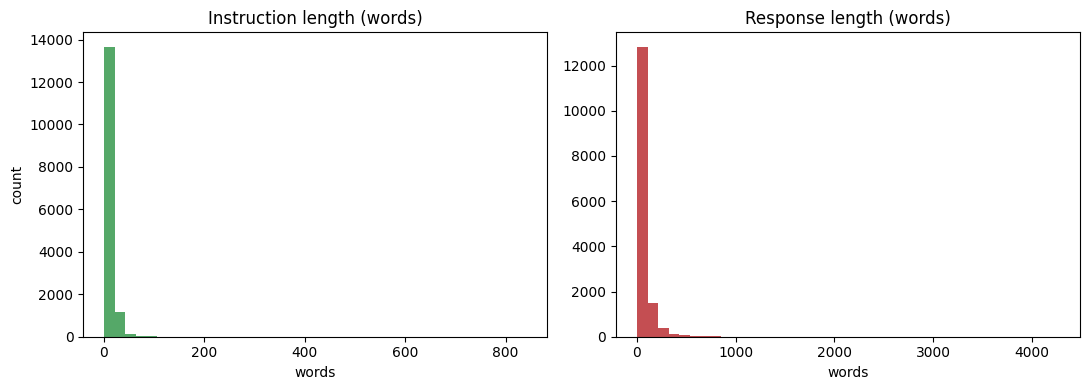

Median instruction length: 10 words
Median response length   : 31 words


In [8]:
# --- Graph 2: instruction / response length histograms -----------------------
instr_word_lens = [len(x.split()) for x in raw_dataset["instruction"]]
resp_word_lens = [len(x.split()) for x in raw_dataset["response"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(instr_word_lens, bins=40, color="#55A868")
axes[0].set_title("Instruction length (words)")
axes[0].set_xlabel("words")
axes[0].set_ylabel("count")

axes[1].hist(resp_word_lens, bins=40, color="#C44E52")
axes[1].set_title("Response length (words)")
axes[1].set_xlabel("words")

plt.tight_layout()
plt.show()

print(f"Median instruction length: {np.median(instr_word_lens):.0f} words")
print(f"Median response length   : {np.median(resp_word_lens):.0f} words")

## 4. Format examples with Gemma's chat template

`google/gemma-2-2b` is the **base** model, so its tokenizer has no built-in chat
template. We build one ourselves, using the same `<start_of_turn>` / `<end_of_turn>`
markers that `google/gemma-2-2b-it` was itself trained with. This is the format the
model needs to learn in order to behave like an instruction-following assistant.

We build **`prompt`** / **`completion`** columns (rather than one merged `text` column)
because TRL's `SFTTrainer` can mask the loss to the `completion` tokens automatically
when the dataset is shaped this way (`completion_only_loss=True`) — we only want the
model to be graded on generating the *answer*, not on reproducing the question.

In [9]:
def format_prompt_completion(example):
    instruction = example["instruction"].strip()
    context = example["context"].strip()
    response = example["response"].strip()

    if context:
        user_turn = f"{instruction}\n\n{context}"
    else:
        user_turn = instruction

    prompt = f"<start_of_turn>user\n{user_turn}<end_of_turn>\n<start_of_turn>model\n"
    completion = f"{response}<end_of_turn>\n"
    return {"prompt": prompt, "completion": completion}


formatted_dataset = raw_dataset.map(
    format_prompt_completion,
    remove_columns=raw_dataset.column_names,
)

print(formatted_dataset[0]["prompt"])
print("---")
print(formatted_dataset[0]["completion"])

Map:   0%|          | 0/15011 [00:00<?, ? examples/s]

<start_of_turn>user
When did Virgin Australia start operating?

Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.<end_of_turn>
<start_of_turn>model

---
Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.<end_of_turn>



In [10]:
# Subsample for a Colab-friendly run. Increase these if you have time/GPU to spare.
N_TRAIN = 2000
N_VAL = 200

shuffled = formatted_dataset.shuffle(seed=SEED)
train_dataset = shuffled.select(range(N_TRAIN))
eval_dataset = shuffled.select(range(N_TRAIN, N_TRAIN + N_VAL))

print("Train examples:", len(train_dataset))
print("Eval examples :", len(eval_dataset))

Train examples: 2000
Eval examples : 200


### Check tokenized sequence lengths

We tokenize a sample to pick a sensible `max_length` for training — long enough to avoid
truncating most examples, short enough to keep memory/time reasonable.

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

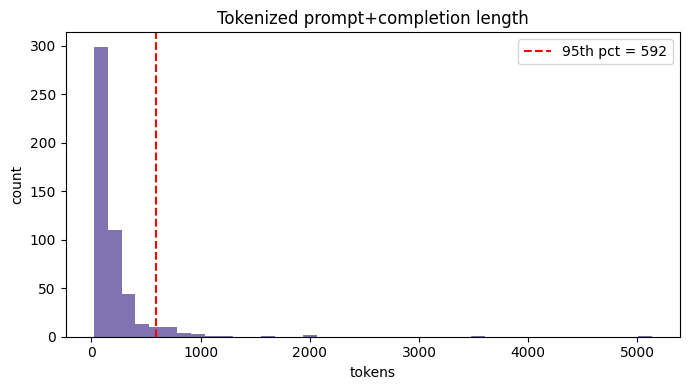

Using MAX_LENGTH = 512
Examples exceeding it: 35 / 500


In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

sample_lengths = [
    len(tokenizer(ex["prompt"] + ex["completion"])["input_ids"])
    for ex in train_dataset.select(range(500))
]

plt.figure(figsize=(7, 4))
plt.hist(sample_lengths, bins=40, color="#8172B2")
plt.axvline(np.percentile(sample_lengths, 95), color="red", linestyle="--",
            label=f"95th pct = {np.percentile(sample_lengths, 95):.0f}")
plt.title("Tokenized prompt+completion length")
plt.xlabel("tokens")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

MAX_LENGTH = 512
print(f"Using MAX_LENGTH = {MAX_LENGTH}")
print(f"Examples exceeding it: {sum(l > MAX_LENGTH for l in sample_lengths)} / {len(sample_lengths)}")

## 5. Load the base model

We load `google/gemma-2-2b` once, in `bf16`. This is the exact object we'll:

1. Probe for **baseline** behavior (this section),
2. Then hand to `SFTTrainer` together with a `LoraConfig` for fine-tuning (Section 7+).

In [12]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    attn_implementation="eager",
    device_map="auto" if DEVICE == "cuda" else None,
)
if DEVICE == "cpu":
    model = model.to(DEVICE)

model.config.use_cache = False  # required for gradient checkpointing during training
print("Loaded:", MODEL_ID)
print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e9, "B")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Loaded: google/gemma-2-2b
Parameters: 2.614341888 B


## 6. Baseline behavior — before any fine-tuning

Let's see how the raw base model handles a few instructions **using the same Gemma chat
format** we're about to fine-tune on. Since the base model was never trained on this
format, expect it to ramble, ignore the turn markers, or continue the "conversation" as
if it were plain text rather than actually answering.

We save these outputs so we can compare them to the fine-tuned model later.

In [13]:
EVAL_PROMPTS = [
    "What is the capital of France?",
    "Write a short poem about the ocean.",
    "Explain what photosynthesis is in one paragraph.",
    "List three tips for staying focused while studying.",
]

def build_prompt(instruction):
    return f"<start_of_turn>user\n{instruction}<end_of_turn>\n<start_of_turn>model\n"

def generate(model, tokenizer, instruction, max_new_tokens=120, temperature=0.7, top_p=0.9):
    prompt = build_prompt(instruction)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature if temperature > 0 else None,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


baseline_generations = {}
for instr in EVAL_PROMPTS:
    baseline_generations[instr] = generate(model, tokenizer, instr)
    print(f"### {instr}")
    print(baseline_generations[instr])
    print()

### What is the capital of France?
What is the capital of France?}");
        var response = await client.GetAsync(url);
        if (response.IsSuccessStatusCode)
        {
            string responseContent = await response.Content.ReadAsStringAsync();
            Console.WriteLine(responseContent);
        }
    }
}
<unused61>}


### Write a short poem about the ocean.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short

### Explain what photosynthesis is in one paragraph.
Explain what the word “photosynthesis” means in one sentence.
Explain what the word “photosynthesis” means in one se

## 7. Baseline next-token logits

Instead of full generations, let's look **directly at the model's output logits** for the
very first token of the response, right after `<start_of_turn>model\n`. This is the
model's raw probability distribution over its vocabulary before it's generated anything —
a very direct window into "what has SFT taught it."

We'll re-run this exact cell's logic after fine-tuning and plot the two side by side.

'What'          0.3197
'Which'         0.0556
'How'           0.0556
'The'           0.0180
'Who'           0.0109
'Where'         0.0097
'Why'           0.0066
'StoryboardSegue' 0.0066
'what'          0.0066
'This'          0.0059


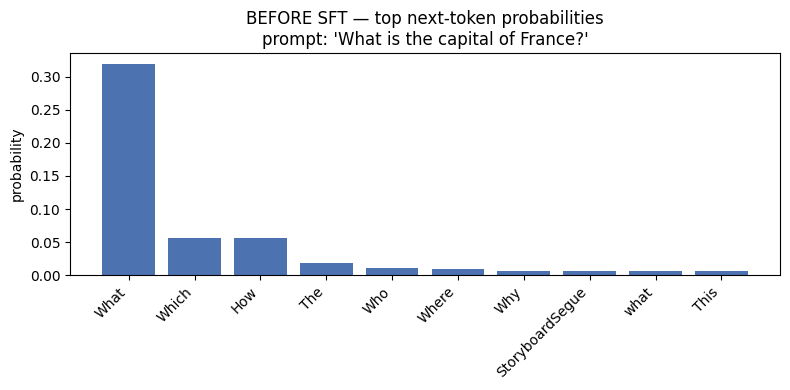

In [14]:
LOGIT_PROMPT = "What is the capital of France?"

def get_top_k_next_token(model, tokenizer, instruction, k=10):
    prompt = build_prompt(instruction)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        logits = model(**inputs).logits
    next_token_logits = logits[0, -1]
    probs = torch.softmax(next_token_logits.float(), dim=-1)
    top_probs, top_ids = torch.topk(probs, k)
    tokens = [tokenizer.decode([tid.item()]) for tid in top_ids]
    return tokens, top_probs.cpu().numpy()

baseline_tokens, baseline_probs = get_top_k_next_token(model, tokenizer, LOGIT_PROMPT)

for tok, p in zip(baseline_tokens, baseline_probs):
    print(f"{tok!r:15s} {p:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(baseline_tokens, baseline_probs, color="#4C72B0")
plt.title(f"BEFORE SFT — top next-token probabilities\nprompt: {LOGIT_PROMPT!r}")
plt.ylabel("probability")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Baseline perplexity on the validation set

Perplexity = `exp(average cross-entropy loss)`, computed **only on the response
(completion) tokens** — the same objective we're about to train on. Lower is better; it's
the standard way to quantify "how surprised is the model by the correct answer."

We compute it on a subset of `eval_dataset` for speed, and reuse this exact function after
fine-tuning.

In [17]:
@torch.no_grad()
def compute_completion_perplexity(model, tokenizer, examples, max_length=512, batch_size=4, device=None):
    device = device or model.device
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for i in range(0, len(examples), batch_size):
        # Use select to subset the dataset slice as a proper list of dictionaries
        batch = [examples[idx] for idx in range(i, min(i + batch_size, len(examples)))]
        input_ids_list, labels_list = [], []

        for ex in batch:
            prompt_ids = tokenizer(ex["prompt"], add_special_tokens=True)["input_ids"]
            completion_ids = tokenizer(ex["completion"], add_special_tokens=False)["input_ids"]
            ids = (prompt_ids + completion_ids)[:max_length]
            labels = ([-100] * len(prompt_ids) + completion_ids)[:max_length]
            input_ids_list.append(ids)
            labels_list.append(labels)

        max_len = max(len(x) for x in input_ids_list)
        pad_id = tokenizer.pad_token_id
        input_ids = torch.full((len(input_ids_list), max_len), pad_id, dtype=torch.long)
        labels = torch.full((len(labels_list), max_len), -100, dtype=torch.long)
        attention_mask = torch.zeros((len(input_ids_list), max_len), dtype=torch.long)

        for j, (ids, labs) in enumerate(zip(input_ids_list, labels_list)):
            input_ids[j, : len(ids)] = torch.tensor(ids)
            labels[j, : len(labs)] = torch.tensor(labs)
            attention_mask[j, : len(ids)] = 1

        input_ids = input_ids.to(device)
        labels = labels.to(device)
        attention_mask = attention_mask.to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)).float(),
            shift_labels.view(-1),
            ignore_index=-100,
            reduction="sum",
        )
        n_tokens = (shift_labels != -100).sum().item()

        total_loss += loss.item()
        total_tokens += n_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    return avg_loss, float(np.exp(avg_loss))


eval_subset = eval_dataset.select(range(min(100, len(eval_dataset))))

baseline_loss, baseline_ppl = compute_completion_perplexity(model, tokenizer, eval_subset)
print(f"Baseline completion loss     : {baseline_loss:.4f}")
print(f"Baseline completion perplexity: {baseline_ppl:.2f}")

Baseline completion loss     : 2.1543
Baseline completion perplexity: 8.62


## 9. Configure LoRA

LoRA freezes the base weights and trains small rank-`r` adapter matrices injected into the
attention and MLP projection layers. `lora_alpha` scales the adapters' contribution, and
`lora_dropout` regularizes them.

In [18]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

print(lora_config)

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.21.0', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'up_proj', 'down_proj', 'o_proj', 'v_proj', 'q_proj', 'k_proj', 'gate_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, kasa_config=None, ensure_weight_ty

## 10. Training configuration (`SFTConfig`)

A few choices worth calling out:

- `completion_only_loss=True` — mask the loss to the `completion` column (see Section 4).
- `packing=False` — keep one example per sequence, which keeps the completion-masking
  logic simple to reason about (packing multiple examples per sequence is a good
  follow-up optimization once you're comfortable with the basics).
- `gradient_checkpointing=True` — trades compute for memory, important on a T4.
- `bf16=True` — matches the dtype we loaded the model in.

In [20]:
OUTPUT_DIR = "./gemma-2-2b-dolly-sft"

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    max_length=MAX_LENGTH,
    packing=False,
    completion_only_loss=True,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=10,
    weight_decay=0.01,
    max_grad_norm=0.3,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="epoch",
    bf16=(DTYPE == torch.bfloat16),
    fp16=False,
    report_to="none",
    seed=SEED,
)

print(training_args)

SFTConfig(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
activation_offloading=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
assistant_only_loss=False,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=False,
chat_template_path=None,
completion_only_loss=True,
data_seed=None,
dataloader_drop_last=False,
dataloader_in_order=True,
dataloader_multiprocessing_context=None,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
dataset_kwargs=None,
dataset_num_proc=None,
dataset_text_field=text,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=Fa

## 11. A small callback to log GPU memory

`Trainer` already logs loss / learning rate / gradient norm into `trainer.state.log_history`
for us. The one thing it doesn't track by default is **GPU memory**, which is useful to see
how LoRA + gradient checkpointing keep memory in check — so we add a tiny custom
callback for it.

In [21]:
class GPUMemoryCallback(TrainerCallback):
    def __init__(self):
        self.records = []  # list of (step, allocated_gb, reserved_gb)

    def on_log(self, args, state, control, logs=None, **kwargs):
        if torch.cuda.is_available():
            allocated = torch.cuda.memory_allocated() / 1e9
            reserved = torch.cuda.memory_reserved() / 1e9
            self.records.append((state.global_step, allocated, reserved))

gpu_mem_callback = GPUMemoryCallback()

## 12. Build the `SFTTrainer`

We pass the **raw base model** plus `peft_config=lora_config` — `SFTTrainer` wraps the
model with LoRA adapters internally. After this cell, `trainer.model` is the
LoRA-wrapped model; the `model` variable we probed above is still the plain base model
we already captured baseline results from.

In [23]:
# Upgrade torchao to resolve the incompatible version check from PEFT
!pip install -q -U torchao

from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=lora_config,
    processing_class=tokenizer,
    callbacks=[gpu_mem_callback],
)

trainer.model.print_trainable_parameters()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.7 MB/s eta 0:00:00


Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

trainable params: 20,766,720 || all params: 2,635,108,608 || trainable%: 0.7881


## 13. Train

Watch the loss in the printed log table below — it should trend down. This is the actual
fine-tuning step; on a T4 with the defaults above, expect somewhere around 15–30 minutes
for `N_TRAIN=2000` examples / 2 epochs (exact time depends on the GPU you're allocated).

In [24]:
train_start = time.time()
train_result = trainer.train()
train_elapsed = time.time() - train_start

print(f"\nTraining finished in {train_elapsed/60:.1f} minutes")
print(train_result)

Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
25,1.765574,1.599676,1.585117,62442.000000,0.628202
50,1.581803,1.585379,1.558687,121940.000000,0.629542
75,1.632875,1.549891,1.578709,185058.000000,0.638697
100,1.654346,1.547422,1.570462,245617.000000,0.637804
125,1.577030,1.533344,1.499132,306563.000000,0.642276
150,1.127968,1.563441,1.325771,367109.000000,0.638876
175,1.397413,1.564858,1.311857,429298.000000,0.640813
200,1.179825,1.569220,1.305826,487798.000000,0.639495
225,1.456638,1.570394,1.307656,548602.000000,0.639368
242,1.403647,1.569913,1.307085,591046.000000,0.638977



Training finished in 19.8 minutes
TrainOutput(global_step=242, training_loss=1.5165081556178321, metrics={'train_runtime': 1189.4722, 'train_samples_per_second': 3.255, 'train_steps_per_second': 0.203, 'total_flos': 1.0306074603773952e+16, 'train_loss': 1.5165081556178321, 'epoch': 2.0})


## 14. Training logs

`trainer.state.log_history` contains every logged training/eval record — loss, learning
rate, gradient norm, epoch, and timing — as a list of dicts. Let's turn it into a proper
table.

In [25]:
log_df = pd.DataFrame(trainer.state.log_history)
pd.set_option("display.max_rows", 200)
log_df

,loss,grad_norm,learning_rate,entropy,num_tokens,mean_token_accuracy,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,eval_entropy,eval_num_tokens,eval_mean_token_accuracy,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.005443,2.021215,8.000000e-05,2.002316,14342.0,0.594693,0.041322,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.783025,2.031614,1.800000e-04,1.977885,25621.0,0.628439,0.082645,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.794905,1.407995,1.998533e-04,1.658113,38380.0,0.626583,0.123967,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.668092,1.080818,1.992583e-04,1.582182,51066.0,0.646571,0.165289,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.765574,1.326451,1.982084e-04,1.613881,62442.0,0.609845,0.206612,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,0.206612,25,1.599676,13.2838,14.830,7.453,1.585117,62442.0,0.628202,NaN,NaN,NaN,NaN,NaN
6,1.845636,1.088128,1.967084e-04,1.587447,77688.0,0.636376,0.247934,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.689510,0.958869,1.947653e-04,1.676198,89511.0,0.612765,0.289256,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.635291,1.365827,1.923880e-04,1.493536,100618.0,0.664645,0.330579,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.628517,1.170296,1.895872e-04,1.520169,110510.0,0.648699,0.371901,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Save the raw logs too, in case you want to inspect them outside the notebook
log_csv_path = os.path.join(OUTPUT_DIR, "training_log_history.csv")
os.makedirs(OUTPUT_DIR, exist_ok=True)
log_df.to_csv(log_csv_path, index=False)
print("Saved:", log_csv_path)

Saved: ./gemma-2-2b-dolly-sft/training_log_history.csv


## 15. Training graphs

Four panels from one training run:

1. **Training loss** vs. step
2. **Eval loss** vs. step (should track training loss without diverging upward — a sign
   of overfitting if it does)
3. **Learning rate schedule** (cosine decay with warmup, as configured)
4. **Gradient norm** (clipped at `max_grad_norm=0.3`) and **GPU memory** over the run

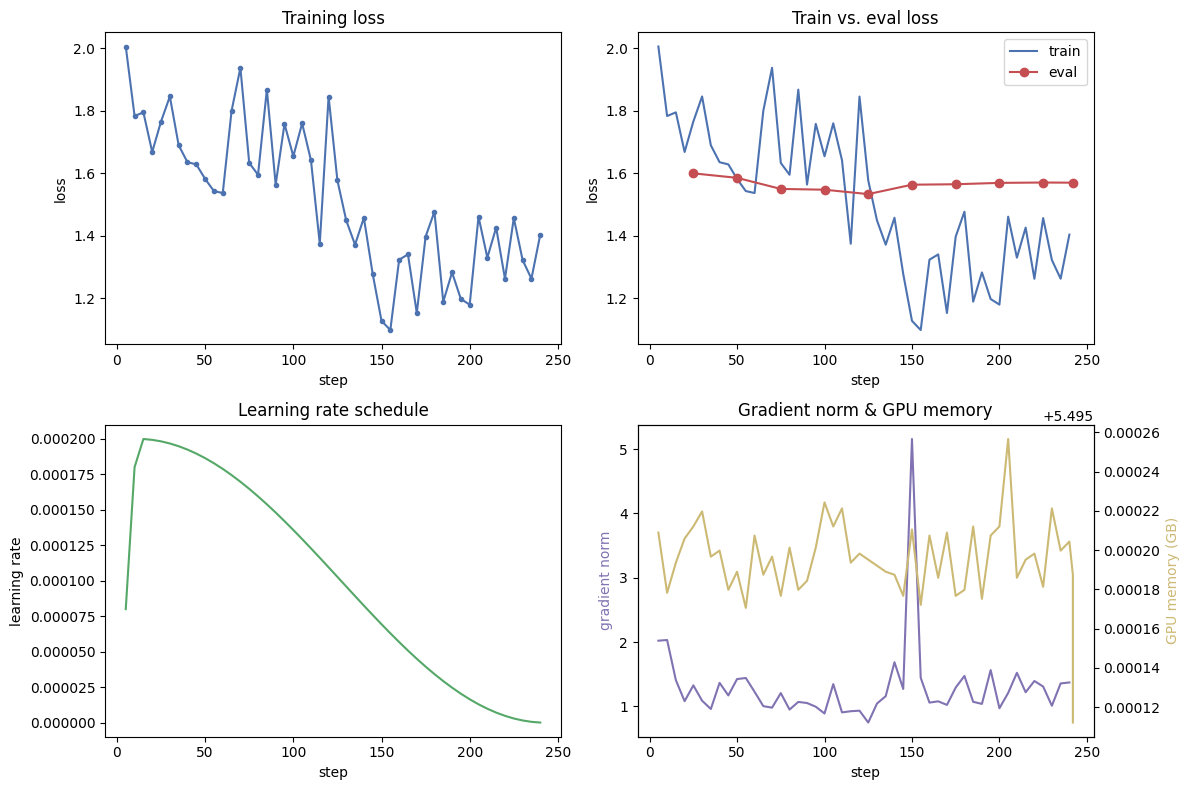

In [27]:
train_logs = log_df[log_df["loss"].notna()] if "loss" in log_df else pd.DataFrame()
eval_logs = log_df[log_df["eval_loss"].notna()] if "eval_loss" in log_df else pd.DataFrame()
lr_logs = log_df[log_df["learning_rate"].notna()] if "learning_rate" in log_df else pd.DataFrame()
grad_logs = log_df[log_df["grad_norm"].notna()] if "grad_norm" in log_df else pd.DataFrame()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Training loss
axes[0, 0].plot(train_logs["step"], train_logs["loss"], marker="o", markersize=3, color="#4C72B0")
axes[0, 0].set_title("Training loss")
axes[0, 0].set_xlabel("step")
axes[0, 0].set_ylabel("loss")

# Training vs eval loss
axes[0, 1].plot(train_logs["step"], train_logs["loss"], label="train", color="#4C72B0")
if not eval_logs.empty:
    axes[0, 1].plot(eval_logs["step"], eval_logs["eval_loss"], label="eval", marker="o", color="#C44E52")
axes[0, 1].set_title("Train vs. eval loss")
axes[0, 1].set_xlabel("step")
axes[0, 1].set_ylabel("loss")
axes[0, 1].legend()

# Learning rate
axes[1, 0].plot(lr_logs["step"], lr_logs["learning_rate"], color="#55A868")
axes[1, 0].set_title("Learning rate schedule")
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("learning rate")

# Gradient norm + GPU memory (twin axis)
ax = axes[1, 1]
if not grad_logs.empty:
    ax.plot(grad_logs["step"], grad_logs["grad_norm"], color="#8172B2", label="grad norm")
    ax.set_ylabel("gradient norm", color="#8172B2")
ax.set_xlabel("step")
ax.set_title("Gradient norm & GPU memory")

if gpu_mem_callback.records:
    mem_steps, mem_alloc, mem_reserved = zip(*gpu_mem_callback.records)
    ax2 = ax.twinx()
    ax2.plot(mem_steps, mem_alloc, color="#CCB974", label="GPU mem allocated (GB)")
    ax2.set_ylabel("GPU memory (GB)", color="#CCB974")

plt.tight_layout()
plt.show()

## 16. Post-SFT behavior — same prompts as Section 6

Now let's ask the fine-tuned model (`trainer.model`, adapters active) the exact same
questions and compare directly with the baseline outputs we saved earlier.

In [28]:
finetuned_model = trainer.model
finetuned_model.eval()

comparison_rows = []
for instr in EVAL_PROMPTS:
    ft_output = generate(finetuned_model, tokenizer, instr)
    comparison_rows.append({
        "instruction": instr,
        "before_sft": baseline_generations[instr],
        "after_sft": ft_output,
    })

comparison_df = pd.DataFrame(comparison_rows)
for _, row in comparison_df.iterrows():
    print(f"### {row['instruction']}")
    print("--- BEFORE SFT ---")
    print(row["before_sft"])
    print("--- AFTER SFT ---")
    print(row["after_sft"])
    print()

### What is the capital of France?
--- BEFORE SFT ---
What is the capital of France?}");
        var response = await client.GetAsync(url);
        if (response.IsSuccessStatusCode)
        {
            string responseContent = await response.Content.ReadAsStringAsync();
            Console.WriteLine(responseContent);
        }
    }
}
<unused61>}

--- AFTER SFT ---
The capital of France is Paris.


### Write a short poem about the ocean.
--- BEFORE SFT ---
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short poem about a model.
Write a short
--- AFTER SFT ---
The ocean, vast and deep,
stretches across the Earth's vastness

## 17. Post-SFT next-token logits — before vs. after, side by side

Same prompt, same helper function as Section 7, now run against the fine-tuned model.

BEFORE SFT:
  'What'          0.3197
  'Which'         0.0556
  'How'           0.0556
  'The'           0.0180
  'Who'           0.0109
  'Where'         0.0097
  'Why'           0.0066
  'StoryboardSegue' 0.0066
  'what'          0.0066
  'This'          0.0059

AFTER SFT:
  'The'           0.6686
  'Paris'         0.2787
  'France'        0.0427
  'La'            0.0013
  'the'           0.0011
  'In'            0.0006
  'Le'            0.0006
  'French'        0.0005
  'It'            0.0004
  'According'     0.0004


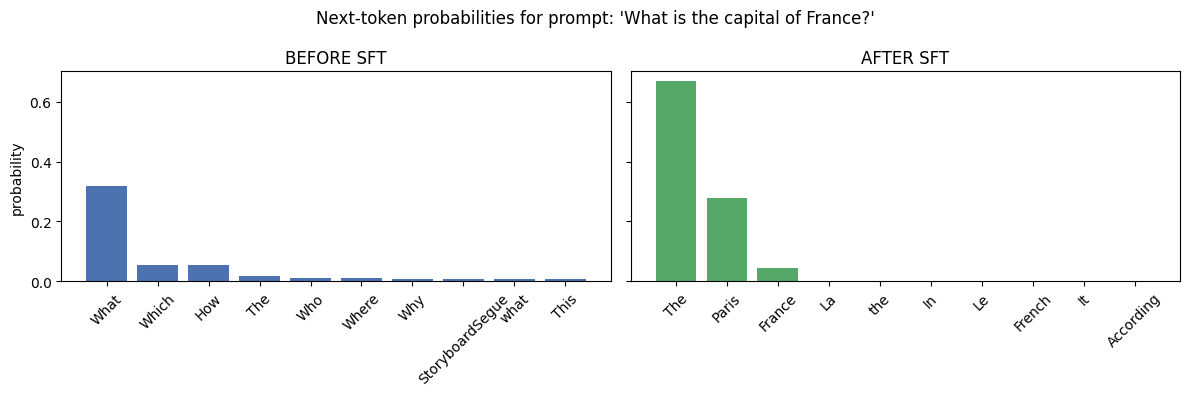

In [29]:
finetuned_tokens, finetuned_probs = get_top_k_next_token(finetuned_model, tokenizer, LOGIT_PROMPT)

print("BEFORE SFT:")
for tok, p in zip(baseline_tokens, baseline_probs):
    print(f"  {tok!r:15s} {p:.4f}")

print("\nAFTER SFT:")
for tok, p in zip(finetuned_tokens, finetuned_probs):
    print(f"  {tok!r:15s} {p:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].bar(baseline_tokens, baseline_probs, color="#4C72B0")
axes[0].set_title("BEFORE SFT")
axes[0].set_ylabel("probability")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(finetuned_tokens, finetuned_probs, color="#55A868")
axes[1].set_title("AFTER SFT")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle(f"Next-token probabilities for prompt: {LOGIT_PROMPT!r}")
plt.tight_layout()
plt.show()

## 18. Post-SFT perplexity — before vs. after

Same validation subset, same `compute_completion_perplexity` function from Section 8.

Before SFT — loss: 2.1543  |  perplexity: 8.62
After SFT  — loss: 1.8275  |  perplexity: 6.22


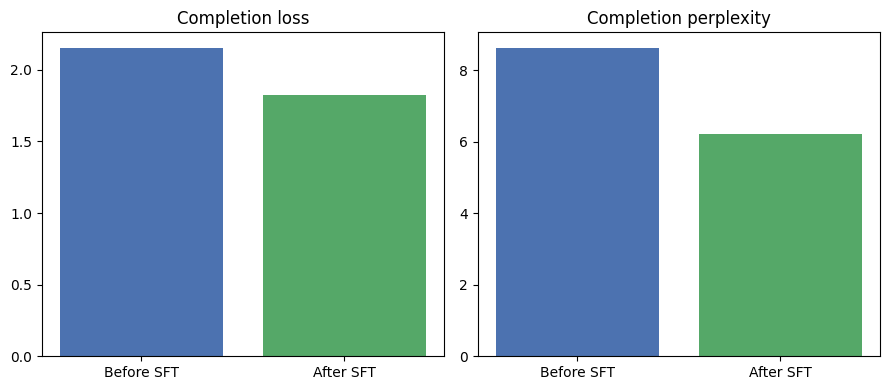

In [30]:
finetuned_loss, finetuned_ppl = compute_completion_perplexity(finetuned_model, tokenizer, eval_subset)

print(f"Before SFT — loss: {baseline_loss:.4f}  |  perplexity: {baseline_ppl:.2f}")
print(f"After SFT  — loss: {finetuned_loss:.4f}  |  perplexity: {finetuned_ppl:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(["Before SFT", "After SFT"], [baseline_loss, finetuned_loss], color=["#4C72B0", "#55A868"])
axes[0].set_title("Completion loss")

axes[1].bar(["Before SFT", "After SFT"], [baseline_ppl, finetuned_ppl], color=["#4C72B0", "#55A868"])
axes[1].set_title("Completion perplexity")

plt.tight_layout()
plt.show()

## 19. Merge the LoRA adapter and save the model

`merge_and_unload()` folds the trained LoRA matrices back into the base weights, giving
you an ordinary standalone `AutoModelForCausalLM` — no PEFT dependency needed to use it
later, and no extra inference-time overhead from the adapter.

In [31]:
MERGED_DIR = "./gemma-2-2b-dolly-sft-merged"

merged_model = finetuned_model.merge_and_unload()
merged_model.save_pretrained(MERGED_DIR)
tokenizer.save_pretrained(MERGED_DIR)

print("Merged model saved to:", MERGED_DIR)
print(os.listdir(MERGED_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged model saved to: ./gemma-2-2b-dolly-sft-merged
['generation_config.json', 'config.json', 'tokenizer_config.json', 'model.safetensors', 'tokenizer.json']


### Optional: push to the Hugging Face Hub

Uncomment and set a repo name to upload your fine-tuned model (you'll need write access
from the token you logged in with in Section 1).

In [32]:
HUB_REPO_ID = "rautaditya/gemma-2-2b-dolly-sft"
merged_model.push_to_hub(HUB_REPO_ID)
tokenizer.push_to_hub(HUB_REPO_ID)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...xwptife/model.safetensors:   1%|          | 32.0MB / 5.23GB            

README.md:   0%|          | 0.00/5.18k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpz0yod146/tokenizer.json:  46%|####6     | 16.0MB / 34.4MB            

CommitInfo(commit_url='https://huggingface.co/rautaditya/gemma-2-2b-dolly-sft/commit/5ac9235854cbf0d9cb44aa3e74e3d55301737582', commit_message='Upload tokenizer', commit_description='', oid='5ac9235854cbf0d9cb44aa3e74e3d55301737582', pr_url=None, repo_url=RepoUrl('https://huggingface.co/rautaditya/gemma-2-2b-dolly-sft', endpoint='https://huggingface.co', repo_type='model', repo_id='rautaditya/gemma-2-2b-dolly-sft'), pr_revision=None, pr_num=None)

## 20. Try your own prompts

Swap in anything you like and compare it with how the base model would have responded.

In [33]:
your_prompt = "Give me three ideas for a weekend trip near the mountains."
print(generate(finetuned_model, tokenizer, your_prompt, max_new_tokens=150))

1. Take a trip to Asheville, North Carolina, which has lots of outdoor activities to do.
2. You could go to Gatlinburg, Tennessee and spend time at Dollywood or take a drive up the mountain to see the Great Smoky Mountains National Park.
3. If you are looking for a longer trip, you could head to Colorado and hike some of the trails in Rocky Mountain National Park.



## What you learned

1. **Why SFT is needed** — a base model predicts plausible next tokens, not "helpful
   answers"; SFT teaches it a specific input/output format using labeled examples.
2. **Data formatting** — building `prompt` / `completion` pairs in Gemma's chat format,
   and why separating them lets the trainer mask the loss to just the response.
3. **LoRA** — freezing the base model and training small low-rank adapters
   (`peft.LoraConfig`) instead of all 2B parameters.
4. **`SFTConfig` / `SFTTrainer`** — the current TRL API (`processing_class`, `max_length`,
   `completion_only_loss`, `packing`) for running the training loop.
5. **Reading training logs** — turning `trainer.state.log_history` into loss curves,
   a learning-rate schedule, gradient-norm tracking, and (via a custom callback) GPU
   memory usage.
6. **Evaluating the effect of fine-tuning three different ways**: generated text,
   raw next-token logits/probabilities, and completion perplexity — all compared
   before vs. after training on identical inputs.
7. **Shipping the result** — merging LoRA weights back into the base model with
   `merge_and_unload()` and saving/optionally pushing a standalone fine-tuned model.

### Where to go from here

- **Bigger run**: raise `N_TRAIN`/`N_VAL`, use the full 15k-example dataset, or train for
  more epochs.
- **QLoRA**: load the base model in 4-bit (`bitsandbytes` + `BitsAndBytesConfig`) to fine-tune
  even larger models on the same GPU.
- **Better data**: swap in a domain-specific instruction dataset for your own use case.
- **Preference tuning**: once you have an SFT model, techniques like DPO or RLHF can
  further align it using pairs of preferred/dispreferred responses — TRL supports both
  (`DPOTrainer`, `PPOTrainer`) with a very similar workflow to what you just did.
- **Quantitative eval**: run the merged model through a benchmark (e.g. via
  `lm-evaluation-harness`) instead of just perplexity/spot-checks.

### Model & dataset references

- Base model: [`google/gemma-2-2b`](https://huggingface.co/google/gemma-2-2b)
- Dataset: [`databricks/databricks-dolly-15k`](https://huggingface.co/datasets/databricks/databricks-dolly-15k)
- Method docs: [TRL SFTTrainer](https://huggingface.co/docs/trl/sft_trainer), [PEFT LoRA](https://huggingface.co/docs/peft/conceptual_guides/lora)